In [1]:
import numpy as np
import pandas as pd
from paraphrase_detection import data_shuffle_split, PairClassifier, Train, TextPairDataset, log_metrics_and_model,\
log_bo_results, BOSearchTrain,plotting_metrics, text_to_df, plotting_distribution_hyperparams,hp_extraction,\
test


import torch
from sentence_transformers import SentenceTransformer
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
from loguru import logger
import os
from transformers import AutoTokenizer
from enums import Optimizer, Scheduler, Model

os.environ["TOKENIZERS_PARALLELISM"] = "false"
from datetime import datetime

In [2]:
df = pd.read_parquet("hf://datasets/sentence-transformers/quora-duplicates/pair-class/train-00000-of-00001.parquet")
data = df.to_numpy()
data = data[:15000]

X = data[:, :2]
y = data[:, 2:3]

X_train, X_val, X_test, y_train, y_val, y_test = data_shuffle_split(X, y, 0.15, 0.12, 42)

### Bayesian Optimization search for CrossEntropy model

In [ ]:
sbert_model = SentenceTransformer("paraphrase-MiniLM-L6-v2")

search_params = ['lr', 'weight_decay', 'dropout_p', 'batch_size', 'n_freeze', 'use_n_layers', 'fc1', 'fc2', 'fc3']

bounds = torch.tensor([
    [1e-4, 0.001, 0.0, 16.0, 3.0, 1.0, 64.0, 64.0, 16.0], #min 
    [3e-2, 0.1, 0.5, 96.99, sbert_model[0].auto_model.config.num_hidden_layers + 0.99, 3.99, 256.99, 128.99, 64.99] #max
])

criterion = torch.nn.CrossEntropyLoss()
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))

bo_searcher = BOSearchTrain(
    bounds = bounds,
    sbert_model = sbert_model,
    X_train = X_train,
    y_train = y_train,
    X_val = X_val,
    y_val = y_val,
    optimizer = Optimizer.ADAMW,
    scheduler = Scheduler.LINEAR,
    criterion = criterion,
    device = device,
    n_init_samples = 10,
    n_iterations = 40,
    fixed = True,
    epochs = 10,
    patience = 2,
    model_arch = Model.CROSSENTROPY
)

best_results = bo_searcher.search_loop()

2025-11-24 09:40:47.574 | INFO     | paraphrase_detection.hyperparameterselection:init_fit_samples:158 - Initial fit of GP for 10 samples of hyperparameter sets 

2025-11-24 09:40:47.575 | INFO     | paraphrase_detection.hyperparameterselection:init_fit_samples:168 - Starting iteration 0:
[('lr', 0.016807109117507935), ('weight_decay', 0.061458710581064224), ('dropout', 0.12752068042755127), ('batch_size', 38), ('n_freeze', 3), ('use_n_layers', 2), ('fc1', 118), ('fc2', 86), ('fc3', 50)]


EPOCH: 0


2025-11-24 09:45:57.627 | INFO     | paraphrase_detection.train:run_training_loop:170 - Epoch 0: train loss = 0.4469384173532045
2025-11-24 09:45:57.627 | INFO     | paraphrase_detection.train:run_training_loop:171 - Epoch 0: validation loss = 0.42779599831384774
2025-11-24 09:45:57.628 | INFO     | paraphrase_detection.train:run_training_loop:172 - Epoch 0: train acc = 0.7844385026737968
2025-11-24 09:45:57.628 | INFO     | paraphrase_detection.train:run_training_loop:173 - Epoch 0: validation acc = 0.8019607843137255
2025-11-24 09:45:57.628 | INFO     | paraphrase_detection.train:run_training_loop:174 - Epoch 0: validation f1 = 0.7812283659869781


EPOCH: 1


2025-11-24 09:51:07.289 | INFO     | paraphrase_detection.train:run_training_loop:170 - Epoch 1: train loss = 0.3960612302015084
2025-11-24 09:51:07.290 | INFO     | paraphrase_detection.train:run_training_loop:171 - Epoch 1: validation loss = 0.41839536191786036
2025-11-24 09:51:07.290 | INFO     | paraphrase_detection.train:run_training_loop:172 - Epoch 1: train acc = 0.8118181818181818
2025-11-24 09:51:07.290 | INFO     | paraphrase_detection.train:run_training_loop:173 - Epoch 1: validation acc = 0.8125490196078431
2025-11-24 09:51:07.291 | INFO     | paraphrase_detection.train:run_training_loop:174 - Epoch 1: validation f1 = 0.7940631249151011


...

2025-11-25 06:34:30.912 | INFO     | paraphrase_detection.train:run_training_loop:170 - Epoch 4: train loss = 0.31458595395088196
2025-11-25 06:34:30.913 | INFO     | paraphrase_detection.train:run_training_loop:171 - Epoch 4: validation loss = 0.37561796831362176
2025-11-25 06:34:30.913 | INFO     | paraphrase_detection.train:run_training_loop:172 - Epoch 4: train acc = 0.8556149732620321
2025-11-25 06:34:30.914 | INFO     | paraphrase_detection.train:run_training_loop:173 - Epoch 4: validation acc = 0.8286274509803921
2025-11-25 06:34:30.914 | INFO     | paraphrase_detection.train:run_training_loop:174 - Epoch 4: validation f1 = 0.8186190436738519


EPOCH: 5


2025-11-25 06:38:17.906 | INFO     | paraphrase_detection.train:run_training_loop:170 - Epoch 5: train loss = 0.29777517141774296
2025-11-25 06:38:17.906 | INFO     | paraphrase_detection.train:run_training_loop:171 - Epoch 5: validation loss = 0.3976773592558774
2025-11-25 06:38:17.906 | INFO     | paraphrase_detection.train:run_training_loop:172 - Epoch 5: train acc = 0.8654545454545455
2025-11-25 06:38:17.907 | INFO     | paraphrase_detection.train:run_training_loop:173 - Epoch 5: validation acc = 0.8231372549019608
2025-11-25 06:38:17.907 | INFO     | paraphrase_detection.train:run_training_loop:174 - Epoch 5: validation f1 = 0.814606472596562


EPOCH: 6


2025-11-25 06:42:04.700 | INFO     | paraphrase_detection.train:run_training_loop:170 - Epoch 6: train loss = 0.2592292930930853
2025-11-25 06:42:04.700 | INFO     | paraphrase_detection.train:run_training_loop:171 - Epoch 6: validation loss = 0.4127778311570485
2025-11-25 06:42:04.701 | INFO     | paraphrase_detection.train:run_training_loop:172 - Epoch 6: train acc = 0.8839572192513369
2025-11-25 06:42:04.701 | INFO     | paraphrase_detection.train:run_training_loop:173 - Epoch 6: validation acc = 0.8282352941176471
2025-11-25 06:42:04.701 | INFO     | paraphrase_detection.train:run_training_loop:174 - Epoch 6: validation f1 = 0.8175907277491392
2025-11-25 06:42:05.144 | WARNING  | paraphrase_detection.train:run_training_loop:185 - EARLY STOP during training at epoch 6
2025-11-25 06:42:05.148 | INFO     | paraphrase_detection.hyperparameterselection:search_loop:386 - 
 Maximum validation F1 score: 0.8186190436738519 



In [ ]:
X_obs = bo_searcher.X_observed.numpy()
X_obs[:, 3:] = np.floor(X_obs[:, 3:])

# Saves best model, HP samples with F1 scores and metrics of best performing model
log_bo_results(
    model_name = f'BO_cosFalse_{datetime.now().strftime("%H-%M-%S")}',
    X_observed = X_obs,
    Y_observed = bo_searcher.Y_observed.numpy(),
    col_names = search_params,
    all_metrics = best_results[1:6],
    params = best_results[0]
)

### Bayesian Optimization search for Cross Attention model

In [3]:
sbert_model = "paraphrase-MiniLM-L6-v2"
actual_model = SentenceTransformer(sbert_model)

search_params = ['lr', 'weight_decay', 'dropout_p', 'batch_size', 'n_freeze', 'use_n_layers', 'fc1', 'fc2', 'fc3', \
                 'use_n_layers_cross_att', 'fc1_cross_att', 'fc2_cross_att']
bounds = torch.tensor([
    [1e-5, 0.001, 0.0, 16.0, 3.0, 1.0, 64.0, 64.0, 16.0, 1, 600, 400], #min 
    [1e-3, 0.1, 0.5, 96.99, actual_model[0].auto_model.config.num_hidden_layers + 0.99, 3.99, 256.99, 128.99, 64.99, 2.99, 900.99, 600.99] #max
])

seed = 41

np.random.seed(seed)
torch.manual_seed(seed)

criterion = torch.nn.CrossEntropyLoss()
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))

bo_searcher = BOSearchTrain(
    bounds = bounds,
    sbert_model = sbert_model,
    X_train = X_train,
    y_train = y_train,
    X_val = X_val,
    y_val = y_val,
    optimizer = Optimizer.ADAMW,
    scheduler = Scheduler.LINEAR,
    criterion = criterion,
    device = device,
    n_init_samples = 10,
    n_iterations = 30,
    fixed = False,
    epochs = 10,
    patience = 2,
    model_arch = Model.CROSSATTENTION
)

best_results = bo_searcher.search_loop()

2025-11-26 09:29:31.678 | INFO     | paraphrase_detection.hyperparameterselection:init_fit_samples:164 - Initial fit of GP for 10 samples of hyperparameter sets 

2025-11-26 09:29:31.679 | INFO     | paraphrase_detection.hyperparameterselection:init_fit_samples:174 - Starting iteration 0:
[('lr', 0.000244081937125884), ('weight_decay', 0.023435181006789207), ('dropout', 0.400265097618103), ('batch_size', 29), ('n_freeze', 4), ('use_n_layers', 3), ('fc1', 88), ('fc2', 112), ('fc3', 55), ('use_n_layers_cross_att', 2), ('fc1_cross_att', 777), ('fc2_cross_att', 539)]


EPOCH: 0


2025-11-26 09:38:45.309 | INFO     | paraphrase_detection.train:run_training_loop:171 - Epoch 0: train loss = 0.6120764900393573
2025-11-26 09:38:45.310 | INFO     | paraphrase_detection.train:run_training_loop:172 - Epoch 0: validation loss = 0.4057598954664086
2025-11-26 09:38:45.310 | INFO     | paraphrase_detection.train:run_training_loop:173 - Epoch 0: train acc = 0.6614973262032086
2025-11-26 09:38:45.310 | INFO     | paraphrase_detection.train:run_training_loop:174 - Epoch 0: validation acc = 0.8098039215686275
2025-11-26 09:38:45.311 | INFO     | paraphrase_detection.train:run_training_loop:175 - Epoch 0: validation f1 = 0.7945418828053942


EPOCH: 1


2025-11-26 09:47:54.965 | INFO     | paraphrase_detection.train:run_training_loop:171 - Epoch 1: train loss = 0.4882182753055287
2025-11-26 09:47:54.966 | INFO     | paraphrase_detection.train:run_training_loop:172 - Epoch 1: validation loss = 0.4153145964977876
2025-11-26 09:47:54.966 | INFO     | paraphrase_detection.train:run_training_loop:173 - Epoch 1: train acc = 0.7694295900178253
2025-11-26 09:47:54.967 | INFO     | paraphrase_detection.train:run_training_loop:174 - Epoch 1: validation acc = 0.8052287581699347
2025-11-26 09:47:54.967 | INFO     | paraphrase_detection.train:run_training_loop:175 - Epoch 1: validation f1 = 0.7976553332824446


...

2025-11-26 19:53:54.009 | INFO     | paraphrase_detection.train:run_training_loop:171 - Epoch 2: train loss = 0.3161234634795359
2025-11-26 19:53:54.009 | INFO     | paraphrase_detection.train:run_training_loop:172 - Epoch 2: validation loss = 0.40347562017648114
2025-11-26 19:53:54.010 | INFO     | paraphrase_detection.train:run_training_loop:173 - Epoch 2: train acc = 0.8614081996434938
2025-11-26 19:53:54.010 | INFO     | paraphrase_detection.train:run_training_loop:174 - Epoch 2: validation acc = 0.8202614379084967
2025-11-26 19:53:54.010 | INFO     | paraphrase_detection.train:run_training_loop:175 - Epoch 2: validation f1 = 0.812514955357839


EPOCH: 3


2025-11-26 19:57:05.239 | INFO     | paraphrase_detection.train:run_training_loop:171 - Epoch 3: train loss = 0.25871896451073034
2025-11-26 19:57:05.240 | INFO     | paraphrase_detection.train:run_training_loop:172 - Epoch 3: validation loss = 0.4219755381345749
2025-11-26 19:57:05.240 | INFO     | paraphrase_detection.train:run_training_loop:173 - Epoch 3: train acc = 0.8907308377896613
2025-11-26 19:57:05.241 | INFO     | paraphrase_detection.train:run_training_loop:174 - Epoch 3: validation acc = 0.8300653594771242
2025-11-26 19:57:05.241 | INFO     | paraphrase_detection.train:run_training_loop:175 - Epoch 3: validation f1 = 0.8215618585557007


EPOCH: 4


2025-11-26 20:00:12.995 | INFO     | paraphrase_detection.train:run_training_loop:171 - Epoch 4: train loss = 0.19857072000879616
2025-11-26 20:00:12.996 | INFO     | paraphrase_detection.train:run_training_loop:172 - Epoch 4: validation loss = 0.4537541257298511
2025-11-26 20:00:12.997 | INFO     | paraphrase_detection.train:run_training_loop:173 - Epoch 4: train acc = 0.9219251336898395
2025-11-26 20:00:12.999 | INFO     | paraphrase_detection.train:run_training_loop:174 - Epoch 4: validation acc = 0.8196078431372549
2025-11-26 20:00:12.999 | INFO     | paraphrase_detection.train:run_training_loop:175 - Epoch 4: validation f1 = 0.8100032215045325
2025-11-26 20:00:13.000 | WARNING  | paraphrase_detection.train:run_training_loop:186 - EARLY STOP during training at epoch 4
2025-11-26 20:00:13.379 | INFO     | paraphrase_detection.hyperparameterselection:search_loop:407 - 
 Maximum validation F1 score: 0.8215618585557007 

2025-11-26 20:00:14.020 | WARNING  | paraphrase_detection.hyperpa

In [5]:
X_obs = bo_searcher.X_observed.numpy()
X_obs[:, 3:] = np.floor(X_obs[:, 3:])

# Saves best model, HP samples with F1 scores and metrics of best performing model
log_bo_results(
    model_name = f'BO_CrossAttention_{datetime.now().strftime("%H-%M-%S")}',
    X_observed = X_obs,
    Y_observed = bo_searcher.Y_observed.numpy(),
    col_names = search_params,
    all_metrics = best_results[1:6],
    params = best_results[0]
)

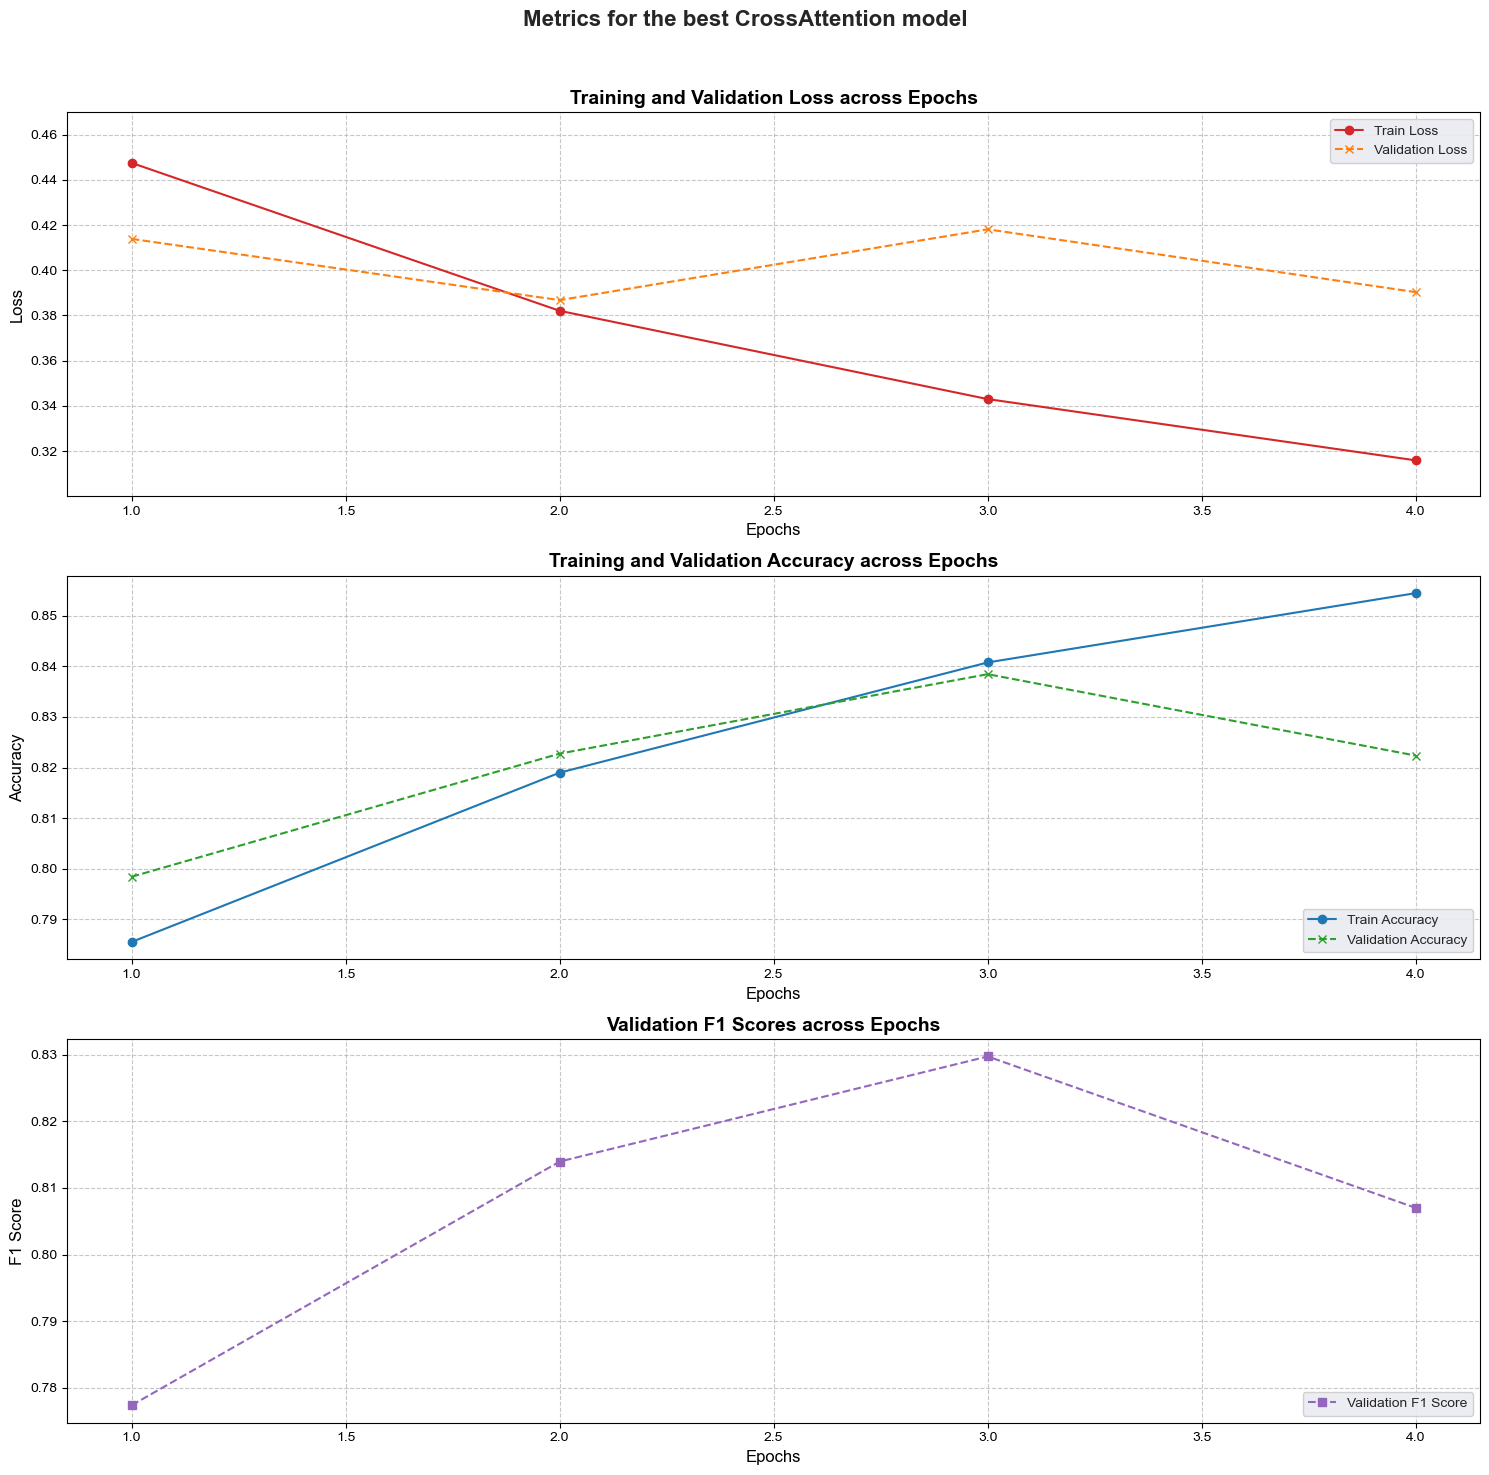

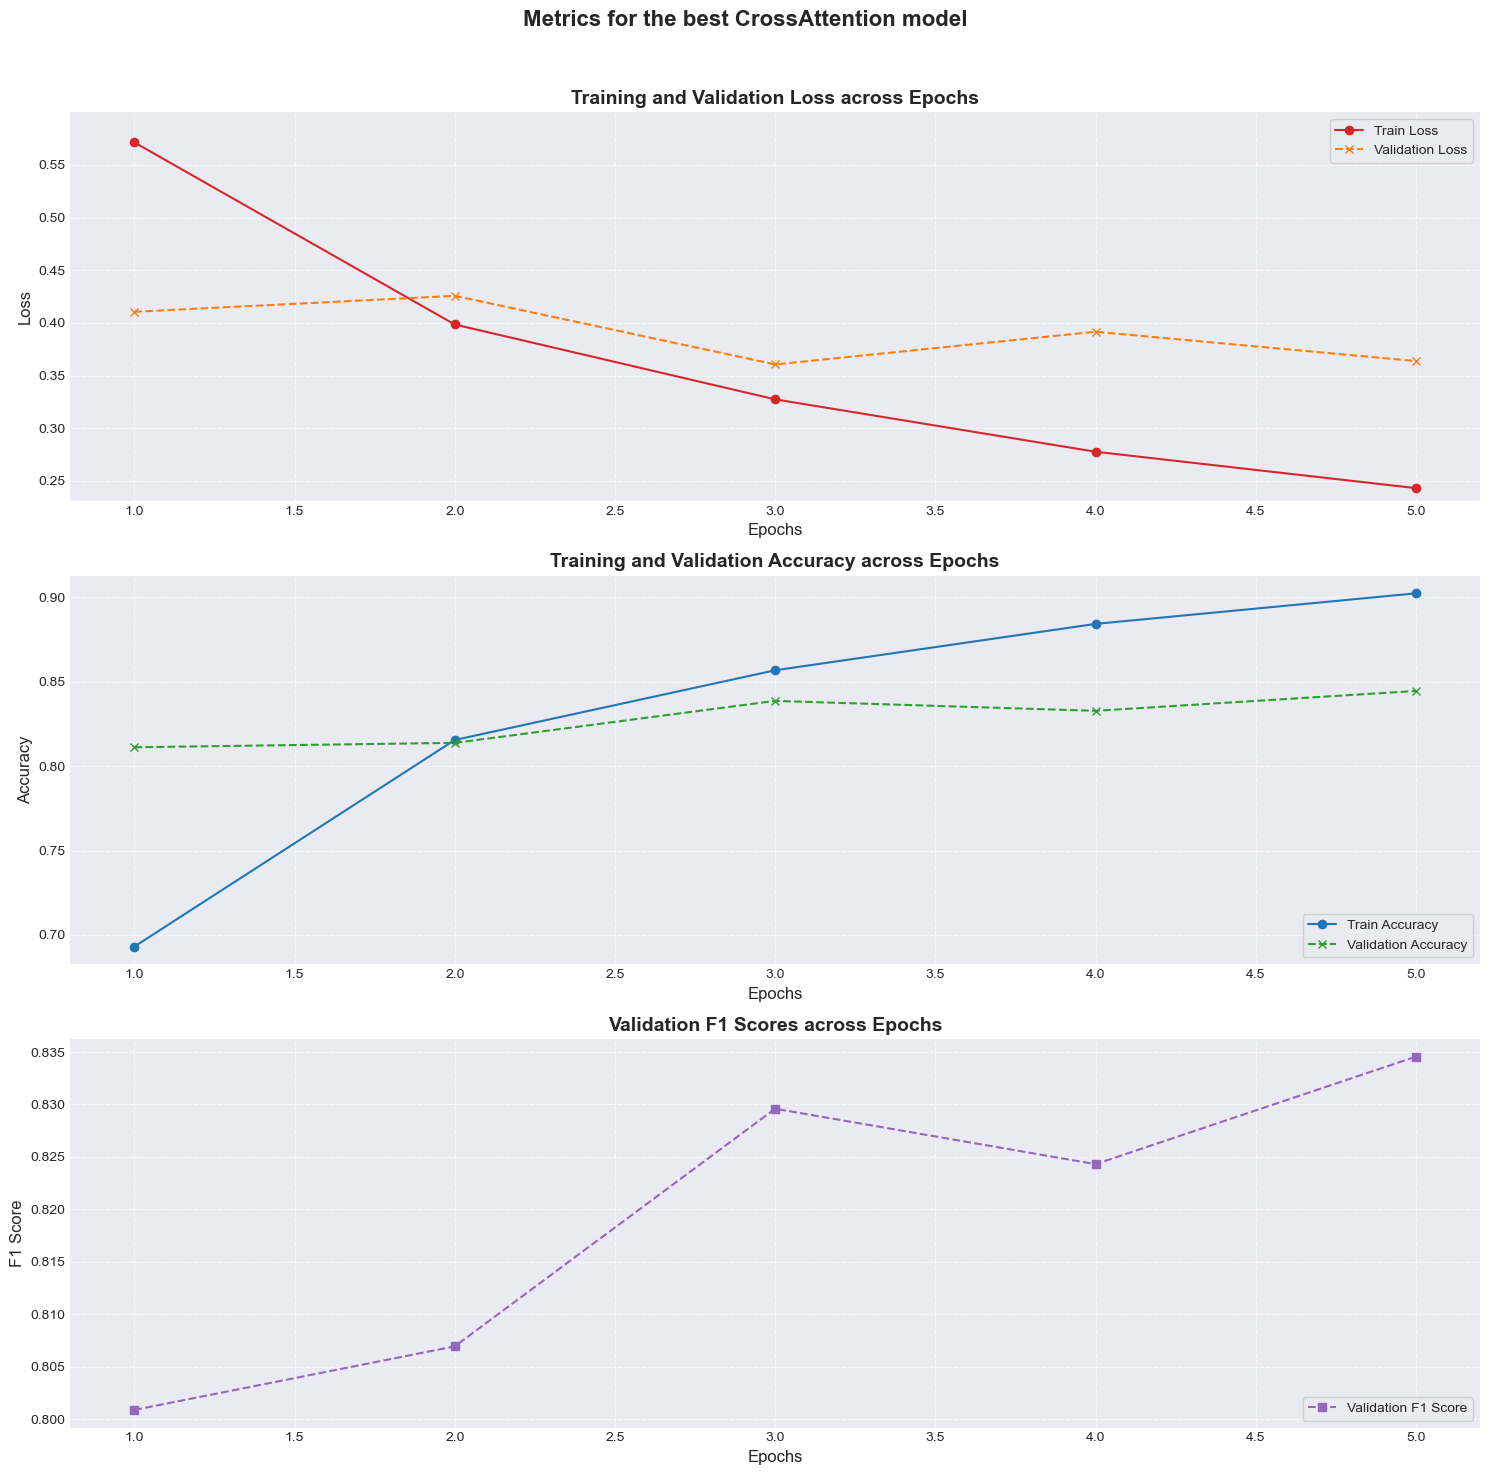

In [2]:
classifier_metrics_df=text_to_df("log/BO_cosFalse_06-42-05_metrics.txt")
cross_attention_metrics_df=text_to_df("log/BO_CrossAttention_20-18-33_metrics.txt")
plotting_metrics(classifier_metrics_df)
plotting_metrics(cross_attention_metrics_df,True)

In [3]:
classifier_hp_df=text_to_df("log/BO_cosFalse_06-42-05_hp.txt")
cross_attention_hp_df=text_to_df("log/BO_CrossAttention_20-18-33_hp.txt")

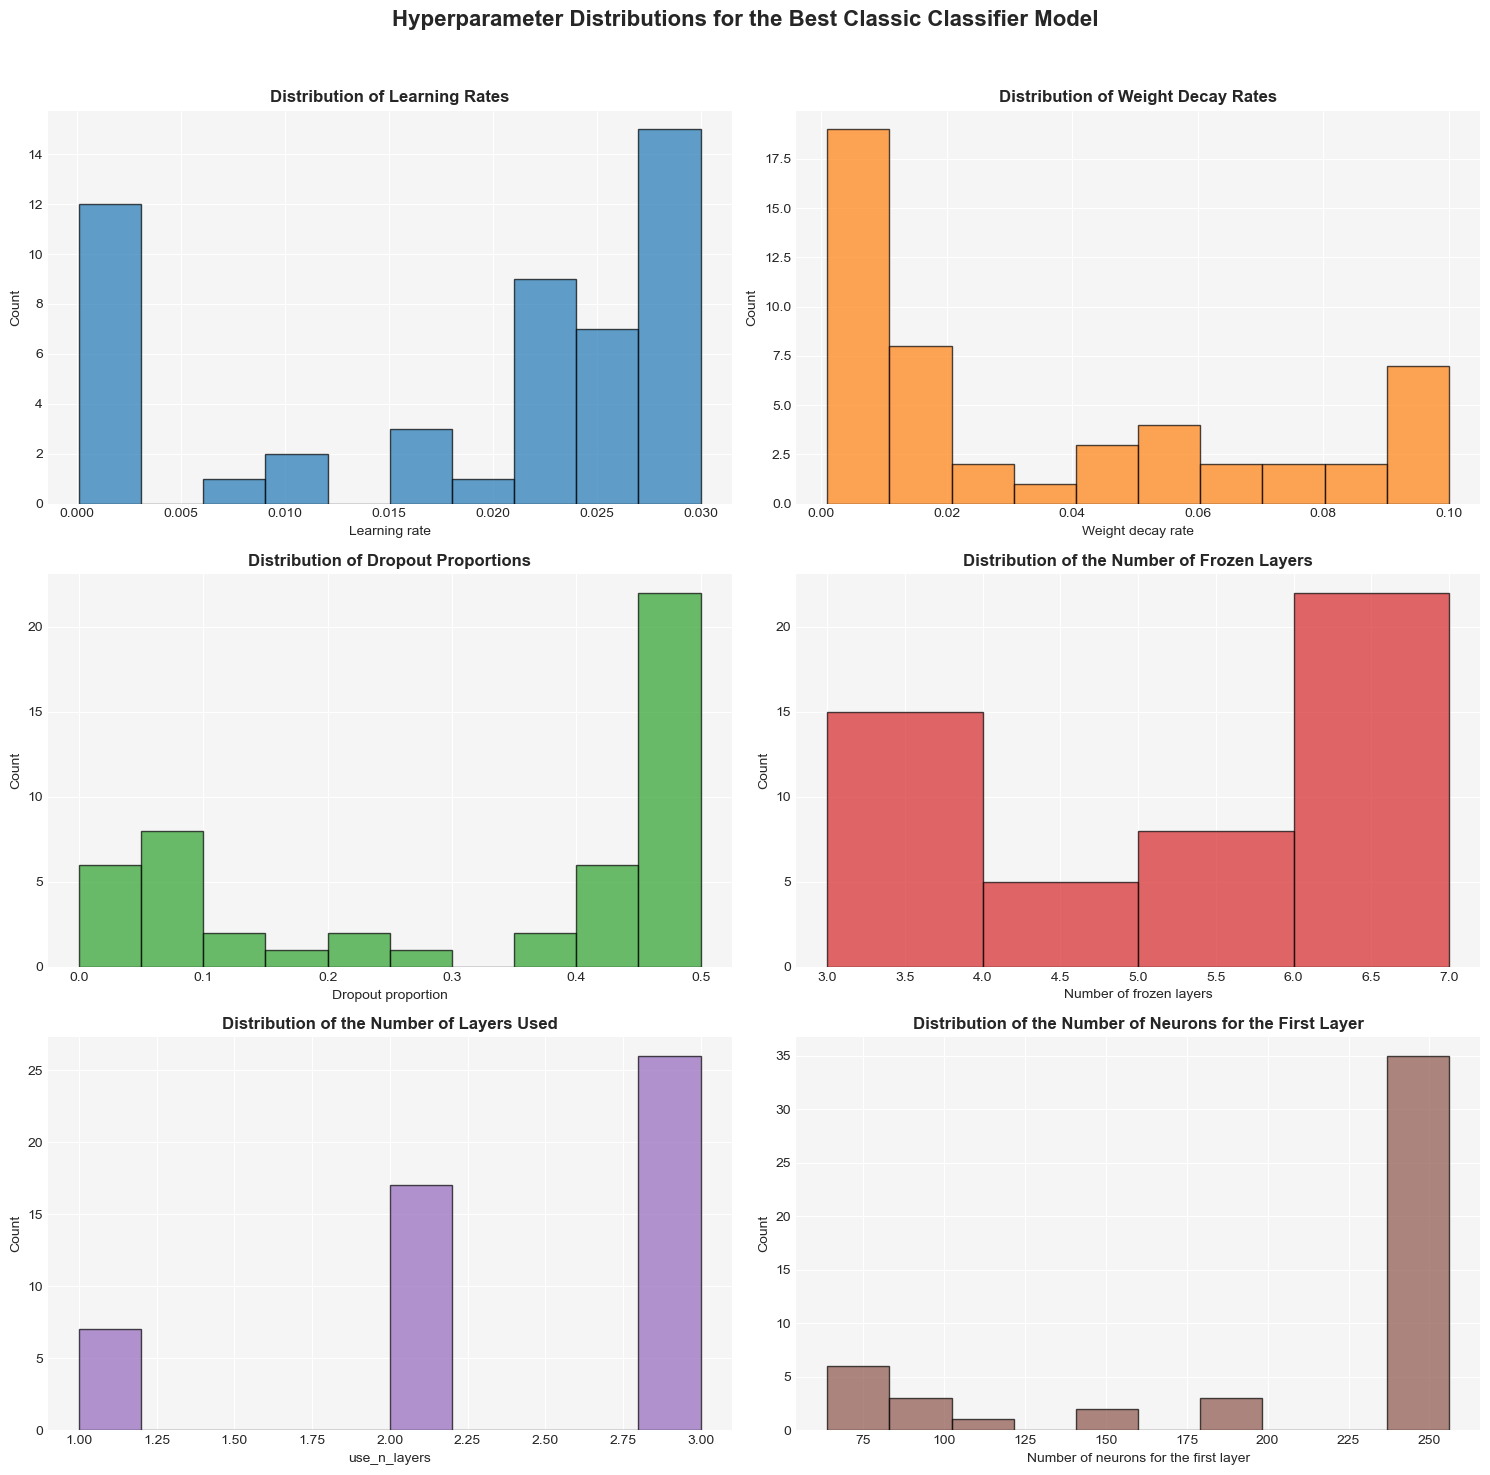

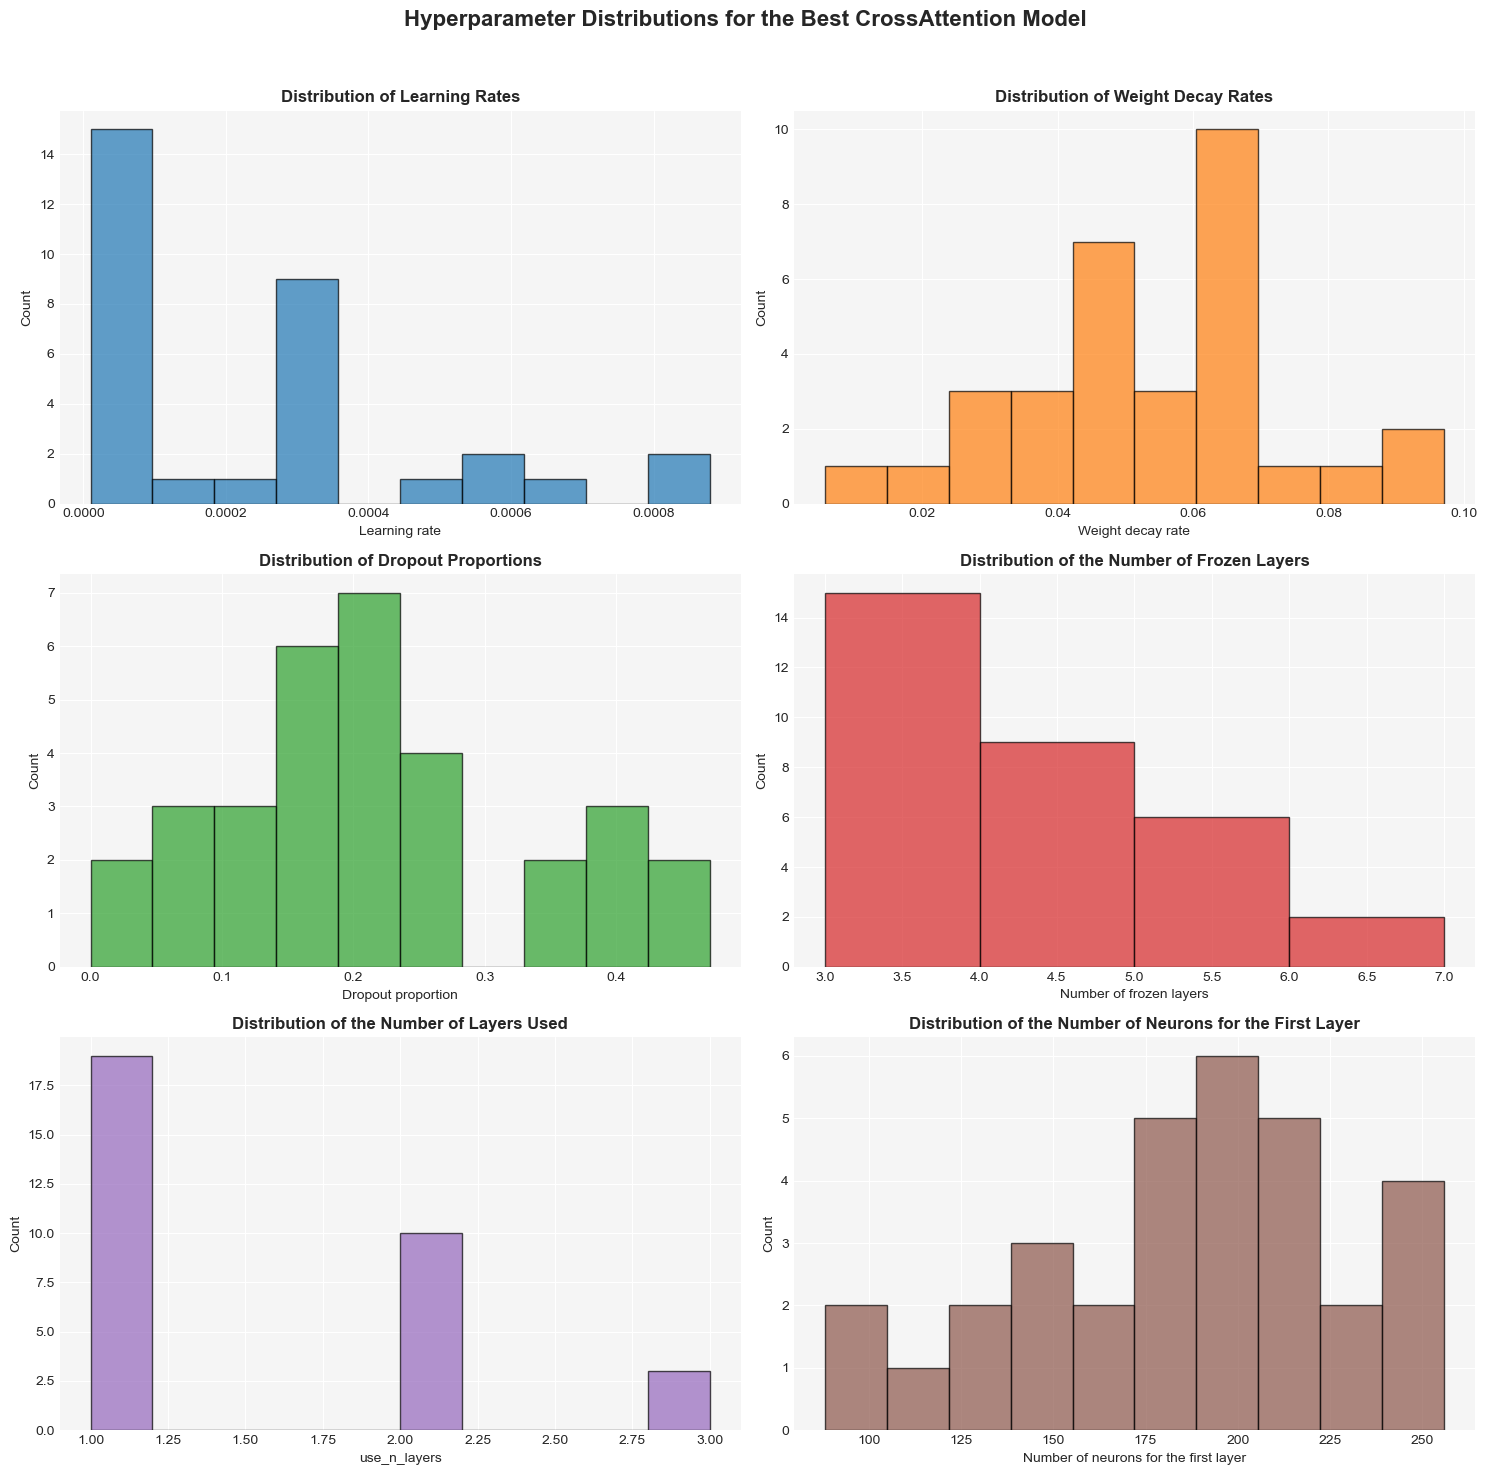

In [5]:
plotting_distribution_hyperparams(classifier_hp_df, False)
plotting_distribution_hyperparams(cross_attention_hp_df)

In [9]:
hp_crossentropy_df=hp_extraction("log/BO_cosFalse_06-42-05_hp.txt")
sbert=SentenceTransformer("paraphrase-MiniLM-L6-v2")
use_n_layers=int(hp_crossentropy_df["use_n_layers"].iloc[0])
fc_sizes=list(hp_crossentropy_df.iloc[:,hp_crossentropy_df.columns.get_loc("fc1"):hp_crossentropy_df.columns.get_loc("fc1")+hp_crossentropy_df["use_n_layers"].iloc[0]].values[0].astype(int))
fc_sizes=[int(size) for size in fc_sizes]
dropout=float(hp_crossentropy_df["dropout_p"].iloc[0])
fixed=False
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))

model_cross_entropy=PairClassifier.CrossEntropy(model=sbert,fc_sizes=fc_sizes,use_n_layers=use_n_layers,device=device,fixed=fixed,dropout=dropout)
state_dict = torch.load("models/BO_cosFalse_06-42-05.pth", map_location=device)
model_cross_entropy.load_state_dict(state_dict=state_dict)


<All keys matched successfully>

In [10]:
if fixed==False:
    tokenization=True
    tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")
else:
    tokenization=False
    tokenizer=None
batch_size=int(hp_crossentropy_df["batch_size"].iloc[0])
test_X_loader=DataLoader(TextPairDataset(X_test,y_test,tokenization=tokenization,tokenizer=tokenizer),batch_size=batch_size,shuffle=True,num_workers=4)
criterion=torch.nn.CrossEntropyLoss()

In [11]:
tester=test(model=model_cross_entropy,
            test_loader=test_X_loader,
            criterion=criterion,
            device=device)
test_accuracy,test_f1,avg_test_loss=tester.run_testing_loop()


print(f"The test loss for the Classic Classifier is {avg_test_loss}")
print(f"The test accuracy for the Classic Classifier is {test_accuracy}")
print(f"The test F1 score for the Classic Classifier is {test_f1}")

The test loss for the Classic Classifier is 0.3123998734213057
The test accuracy for the Classic Classifier is 0.8631111111111112
The test F1 score for the Classic Classifier is 0.8227848101265822


In [12]:
hp_cross_attention_df=hp_extraction("log/BO_CrossAttention_20-18-33_hp.txt")
sbert=SentenceTransformer("paraphrase-MiniLM-L6-v2")
use_n_layers=int(hp_cross_attention_df["use_n_layers"].iloc[0])
fc_sizes=list(hp_cross_attention_df.iloc[:,hp_cross_attention_df.columns.get_loc("fc1"):hp_cross_attention_df.columns.get_loc("fc1")+hp_cross_attention_df["use_n_layers"].iloc[0]].values[0].astype(int))
dropout=float(hp_cross_attention_df["dropout_p"].iloc[0])
fixed=False
use_n_layers_cross_att=int(hp_cross_attention_df["use_n_layers_cross_att"].iloc[0])
fc_sizes_cross_att=list(hp_cross_attention_df.iloc[:,hp_cross_attention_df.columns.get_loc("fc1_cross_att"):hp_cross_attention_df.columns.get_loc("fc1_cross_att")+hp_cross_attention_df["use_n_layers_cross_att"].iloc[0]].values[0].astype(int))
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))

model_cross_attention=PairClassifier.CrossAttention(model=sbert,fc_sizes=fc_sizes,use_n_layers=use_n_layers,device=device,fixed=fixed,dropout=dropout, use_n_layers_cross_att=use_n_layers_cross_att,fc_sizes_cross_att=fc_sizes_cross_att)
state_dict = torch.load("models/BO_CrossAttention_20-18-33.pth", map_location=device)
model_cross_attention.load_state_dict(state_dict=state_dict)



<All keys matched successfully>

In [13]:
if fixed==False:
    tokenization=True
    tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")
else:
    tokenization=False
    tokenizer=None
batch_size=int(hp_cross_attention_df["batch_size"].iloc[0])
test_X_loader=DataLoader(TextPairDataset(X_test,y_test,tokenization=tokenization,tokenizer=tokenizer),batch_size=batch_size,shuffle=True,num_workers=4)
criterion=torch.nn.CrossEntropyLoss()

In [14]:
tester=test(model=model_cross_attention,
            test_loader=test_X_loader,
            criterion=criterion,
            device=device)
test_accuracy,test_f1,avg_test_loss=tester.run_testing_loop()


print(f"The test loss for the Cross Attention Classifier is {avg_test_loss}")
print(f"The test accuracy for the Cross Attention Classifier is {test_accuracy}")
print(f"The test F1 score for the Cross Attention Classifier is {test_f1}")

The test loss for the Cross Attention Classifier is 0.37619238744179406
The test accuracy for the Cross Attention Classifier is 0.8453333333333334
The test F1 score for the Cross Attention Classifier is 0.8170347003154573
